# Técnica de Interdependencia: PCA (Principal Component Analysis) - Con Imputación

- **Dataset original (con dropna)**: `dataset_wide_con_temporada.csv`

**NOTA IMPORTANTE**: Este notebook utiliza datos con **imputación** (método híbrido: interpolación lineal + KNN) en lugar de eliminar valores faltantes con `dropna()`.- **Objetivo**: Comparar resultados del PCA con/sin imputación

- **Archivo de datos**: Dataset wide con temporada generado a partir de datos imputados

## Importación de Librerías

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import bartlett
from factor_analyzer import calculate_kmo

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Carga de Datos

In [55]:
# Cargar dataset CON IMPUTACIÓN
# CAMBIO: Usar archivo agregado con datos imputados
df = pd.read_csv('../data_processed/datos_aggregados_dia_estacion_franja_imputado.csv', parse_dates=['date'])

print("Cargando datos CON IMPUTACIÓN")
print(f"Dimensiones del dataset: {df.shape}")

print(f"Columnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Cargando datos CON IMPUTACIÓN
Dimensiones del dataset: (10944, 9)
Columnas: ['date', 'estacion', 'franja_horaria', 'clase', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5']

Primeras filas:


,date,estacion,franja_horaria,clase,CO,NO2,O3,PM10,PM2.5
0,2023-01-01,CENTRO,fuera_pico_10_12,0,0.960000,10.950000,26.500000,42.500000,11.175
1,2023-01-01,CENTRO,pico_7_9,0,1.010000,12.950000,17.500000,63.500000,24.115
2,2023-01-01,NORESTE3,fuera_pico_10_12,0,1.116667,18.233333,26.666667,84.666667,38.250
3,2023-01-01,NORESTE3,pico_7_9,0,1.604833,25.666667,7.783333,122.666667,79.000
4,2023-01-01,NOROESTE3,fuera_pico_10_12,0,1.171667,10.483333,22.833333,51.333333,16.695


In [56]:
# Información del dataset
print("Información del dataset:")
print(df.info())
print("\n" + "="*50)
print("\nEstadísticas descriptivas:")
df.describe()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10944 entries, 0 to 10943
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            10944 non-null  datetime64[ns]
 1   estacion        10944 non-null  object        
 2   franja_horaria  10944 non-null  object        
 3   clase           10944 non-null  int64         
 4   CO              10944 non-null  float64       
 5   NO2             10944 non-null  float64       
 6   O3              10944 non-null  float64       
 7   PM10            10944 non-null  float64       
 8   PM2.5           10944 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 769.6+ KB
None


Estadísticas descriptivas:


,date,clase,CO,NO2,O3,PM10,PM2.5
count,10944,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000
mean,2024-03-31 11:59:59.999999744,0.497990,1.389172,18.259697,20.094697,67.391277,22.914431
min,2023-01-01 00:00:00,0.000000,0.115000,0.100000,1.000000,3.000000,2.000000
25%,2023-08-16 18:00:00,0.000000,0.842500,11.350000,10.250000,40.500000,12.547083
50%,2024-03-31 12:00:00,0.000000,1.195000,16.350000,17.500000,59.000000,20.500000
75%,2024-11-14 06:00:00,1.000000,1.806542,23.250000,27.500000,84.500000,30.064375
max,2025-06-30 00:00:00,1.000000,5.185000,97.400000,93.875000,599.500000,222.005000
std,NaN,0.500019,0.715640,9.296616,12.572970,41.474741,14.003481


In [57]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())
print(f"\n% de valores faltantes:")
print((df.isnull().sum() / len(df) * 100).round(2))

Valores faltantes por columna:
date              0
estacion          0
franja_horaria    0
clase             0
CO                0
NO2               0
O3                0
PM10              0
PM2.5             0
dtype: int64

% de valores faltantes:
date              0.0
estacion          0.0
franja_horaria    0.0
clase             0.0
CO                0.0
NO2               0.0
O3                0.0
PM10              0.0
PM2.5             0.0
dtype: float64


# Validación de Supuestos del PCA

Antes de aplicar PCA, es necesario validar que los datos cumplan con los supuestos necesarios.

## Preparación de Datos para PCA

Seleccionamos solo las variables de contaminantes para el análisis PCA.

In [58]:
# Definir las variables de contaminantes para el PCA
contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

# CAMBIO: NO eliminamos valores faltantes, usamos datos imputados
# Filtrar solo franja pico (si existe esa columna)
if 'franja_horaria' in df.columns:
    df_pca = df[df['franja_horaria'] == 'pico_7_9'].copy()
    print(f"✓ Filtrando por franja horaria 'pico_7_9'")
else:
    df_pca = df.copy()
    print("⚠ Columna 'franja_horaria' no encontrada, usando todo el dataset")

# Agregar columna de temporada si no existe
if 'temporada' not in df_pca.columns:
    # Crear columna temporada basada en el mes
    df_pca['temporada'] = df_pca['date'].dt.month.map(
        lambda x: 'verano' if x in [4, 5, 6, 7, 8, 9] else 'invierno'
    )
    print("✓ Columna 'temporada' creada (verano: abril-septiembre, invierno: octubre-marzo)")

print(f"\nDimensiones del dataset para PCA: {df_pca.shape}")
print(f"Valores faltantes en contaminantes:")
for cont in contaminantes:
    if cont in df_pca.columns:
        missing = df_pca[cont].isnull().sum()
        pct = (missing / len(df_pca) * 100)
        print(f"  {cont}: {missing} ({pct:.2f}%)")
    else:
        print(f"  {cont}: columna no encontrada")

# Verificar que tenemos los contaminantes
contaminantes_disponibles = [c for c in contaminantes if c in df_pca.columns]
print(f"\nContaminantes disponibles para PCA: {contaminantes_disponibles}")

# Extraer matriz de datos para análisis
X = df_pca[contaminantes].values
print(f"\nMatriz X: {X.shape}")

✓ Filtrando por franja horaria 'pico_7_9'
✓ Columna 'temporada' creada (verano: abril-septiembre, invierno: octubre-marzo)

Dimensiones del dataset para PCA: (5472, 10)
Valores faltantes en contaminantes:
  CO: 0 (0.00%)
  NO2: 0 (0.00%)
  O3: 0 (0.00%)
  PM10: 0 (0.00%)
  PM2.5: 0 (0.00%)

Contaminantes disponibles para PCA: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

Matriz X: (5472, 5)


## Test KMO (Kaiser-Meyer-Olkin)

Evalúa si las correlaciones entre variables son lo suficientemente fuertes como para justificar la reducción de dimensionalidad.

**Interpretación:**
- KMO ≥ 0.90: Excelente
- KMO ≥ 0.80: Muy bueno
- KMO ≥ 0.70: Aceptable
- KMO ≥ 0.60: Mediocre
- KMO < 0.50: Inaceptable

In [59]:
# Calcular KMO
kmo_all, kmo_model = calculate_kmo(X)

print("=" * 60)
print("TEST KMO (Kaiser-Meyer-Olkin)")
print("=" * 60)
print(f"\nKMO Global: {kmo_model:.4f}")

# Interpretación
if kmo_model >= 0.90:
    interpretacion = "Excelente - PCA altamente recomendado"
elif kmo_model >= 0.80:
    interpretacion = "Muy bueno - PCA muy apropiado"
elif kmo_model >= 0.70:
    interpretacion = "Aceptable - PCA apropiado"
elif kmo_model >= 0.60:
    interpretacion = "Mediocre - PCA puede aplicarse con precaución"
else:
    interpretacion = "Inaceptable - PCA no recomendado"

print(f"Interpretación: {interpretacion}")

print(f"\nKMO por variable:")
for i, var in enumerate(contaminantes):
    print(f"  {var}: {kmo_all[i]:.4f}")

TEST KMO (Kaiser-Meyer-Olkin)

KMO Global: 0.6997
Interpretación: Mediocre - PCA puede aplicarse con precaución

KMO por variable:
  CO: 0.8121
  NO2: 0.7232
  O3: 0.6749
  PM10: 0.6658
  PM2.5: 0.6800


## Prueba de Esfericidad de Bartlett

Verificar que la matriz de correlación no es una matriz identidad, es decir, que existe correlación significativa entre las variables.

**Hipótesis:**
- H₀: La matriz de correlación es una matriz identidad (no hay correlación)
- H₁: Existe correlación entre las variables

**Interpretación:**
- Si p-valor < 0.05: Rechazamos H₀, las variables están correlacionadas (PCA apropiado)

In [60]:
# Prueba de esfericidad de Bartlett
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(X)

print("=" * 60)
print("PRUEBA DE ESFERICIDAD DE BARTLETT")
print("=" * 60)
print(f"\nChi-cuadrado: {chi_square_value:.2f}")
print(f"p-valor: {p_value:.2e}")

if p_value < 0.05:
    print("\n✓ Resultado: Rechazamos H₀")
    print("  Las variables están significativamente correlacionadas.")
    print("  PCA es apropiado para este dataset.")
else:
    print("\n✗ Resultado: No rechazamos H₀")
    print("  No hay evidencia suficiente de correlación entre variables.")
    print("  PCA podría no ser apropiado.")

PRUEBA DE ESFERICIDAD DE BARTLETT

Chi-cuadrado: 7079.90
p-valor: 0.00e+00

✓ Resultado: Rechazamos H₀
  Las variables están significativamente correlacionadas.
  PCA es apropiado para este dataset.


## Matriz de Correlación

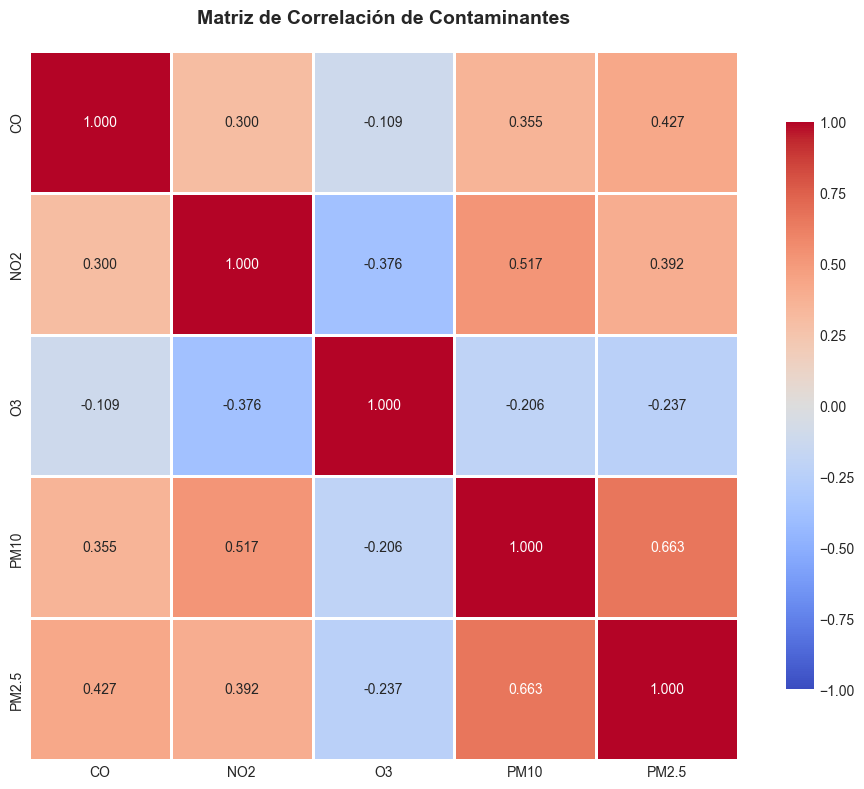


Matriz de Correlación:
             CO       NO2        O3      PM10     PM2.5
CO     1.000000  0.299961 -0.109484  0.355086  0.427289
NO2    0.299961  1.000000 -0.376129  0.516983  0.392350
O3    -0.109484 -0.376129  1.000000 -0.205876 -0.236707
PM10   0.355086  0.516983 -0.205876  1.000000  0.663101
PM2.5  0.427289  0.392350 -0.236707  0.663101  1.000000
             CO       NO2        O3      PM10     PM2.5
CO     1.000000  0.299961 -0.109484  0.355086  0.427289
NO2    0.299961  1.000000 -0.376129  0.516983  0.392350
O3    -0.109484 -0.376129  1.000000 -0.205876 -0.236707
PM10   0.355086  0.516983 -0.205876  1.000000  0.663101
PM2.5  0.427289  0.392350 -0.236707  0.663101  1.000000


In [61]:
# Calcular matriz de correlación
corr_matrix = df_pca[contaminantes].corr()

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Contaminantes', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nMatriz de Correlación:")
print(corr_matrix)

## Estandarización de Variables

Transformamos cada variable para que tenga media = 0 y desviación estándar = 1.

In [62]:
# Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear DataFrame con datos estandarizados
df_scaled = pd.DataFrame(X_scaled, columns=contaminantes, index=df_pca.index)

print("Datos originales:")
print(df_pca[contaminantes].describe())
print("\n" + "="*60 + "\n")
print("Datos estandarizados:")
print(df_scaled.describe())

# Verificar estandarización
print("\n" + "="*60)
print("Verificación de estandarización:")
print("="*60)
print(f"Medias (deben ser ≈ 0):")
print(df_scaled.mean())
print(f"\nDesviaciones estándar (deben ser ≈ 1):")
print(df_scaled.std())

Datos originales:
                CO          NO2           O3         PM10        PM2.5
count  5472.000000  5472.000000  5472.000000  5472.000000  5472.000000
mean      1.393513    18.461564    12.531632    60.486420    21.172576
std       0.721252     8.627100     7.231601    35.504196    12.875772
min       0.115000     0.100000     1.000000     3.000000     2.000000
25%       0.833094    11.990625     7.250000    37.000000    11.500000
50%       1.197500    16.900000    10.891667    53.500000    18.615000
75%       1.820885    23.733333    16.127083    77.000000    28.185000
max       4.975000    58.075000    47.500000   567.333333   124.100000


Datos estandarizados:
                 CO           NO2            O3          PM10         PM2.5
count  5.472000e+03  5.472000e+03  5.472000e+03  5.472000e+03  5.472000e+03
mean   9.868649e-17 -2.077610e-16  2.129551e-16  2.441192e-16 -6.492532e-17
std    1.000091e+00  1.000091e+00  1.000091e+00  1.000091e+00  1.000091e+00
min   -1.772792

# PCA General (Dataset Completo)

Identificar patrones conjuntos dentro del sistema de contaminantes

## Aplicación del PCA

In [63]:
# Aplicar PCA con todos los componentes
pca_full = PCA()
X_pca = pca_full.fit_transform(X_scaled)

# Crear DataFrame con componentes principales
componentes_nombres = [f'PC{i+1}' for i in range(pca_full.n_components_)]
df_pca_scores = pd.DataFrame(X_pca, columns=componentes_nombres, index=df_pca.index)

print("=" * 60)
print("PCA - INFORMACIÓN GENERAL")
print("=" * 60)
print(f"\nNúmero de componentes principales: {pca_full.n_components_}")
print(f"Varianza explicada por cada componente:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")
    
print(f"\nVarianza acumulada:")
for i, var in enumerate(np.cumsum(pca_full.explained_variance_ratio_)):
    print(f"  PC1-PC{i+1}: {var*100:.2f}%")

PCA - INFORMACIÓN GENERAL

Número de componentes principales: 5
Varianza explicada por cada componente:
  PC1: 49.89%
  PC2: 19.32%
  PC3: 13.62%
  PC4: 11.21%
  PC5: 5.96%

Varianza acumulada:
  PC1-PC1: 49.89%
  PC1-PC2: 69.21%
  PC1-PC3: 82.84%
  PC1-PC4: 94.04%
  PC1-PC5: 100.00%


## Scree Plot y Varianza Explicada

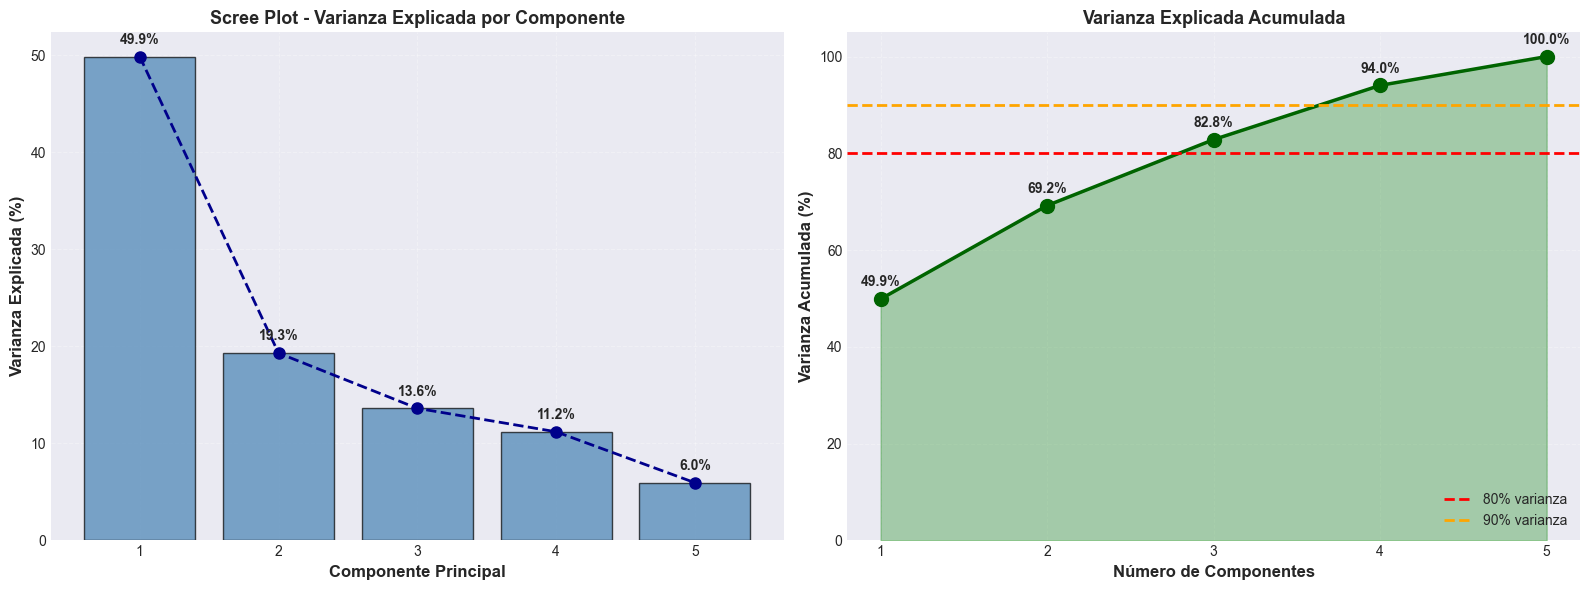


RESUMEN DE VARIANZA EXPLICADA
PC1: 49.89% | Acumulada: 49.89%
PC2: 19.32% | Acumulada: 69.21%
PC3: 13.62% | Acumulada: 82.84%
PC4: 11.21% | Acumulada: 94.04%
PC5: 5.96% | Acumulada: 100.00%


In [64]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Varianza explicada por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_ * 100,
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
             pca_full.explained_variance_ratio_ * 100,
             marker='o', linestyle='--', color='darkblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Scree Plot - Varianza Explicada por Componente', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))

# Añadir valores en las barras
for i, v in enumerate(pca_full.explained_variance_ratio_ * 100):
    axes[0].text(i + 1, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Varianza acumulada
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 
             marker='o', linestyle='-', color='darkgreen', linewidth=2.5, markersize=10)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% varianza')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% varianza')
axes[1].fill_between(range(1, len(cumsum_var) + 1), cumsum_var, alpha=0.3, color='green')
axes[1].set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Varianza Explicada Acumulada', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].set_xticks(range(1, len(cumsum_var) + 1))
axes[1].set_ylim([0, 105])

# Añadir valores en los puntos
for i, v in enumerate(cumsum_var):
    axes[1].text(i + 1, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Resumen
print("\n" + "=" * 60)
print("RESUMEN DE VARIANZA EXPLICADA")
print("=" * 60)
for i in range(len(pca_full.explained_variance_ratio_)):
    print(f"PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}% | Acumulada: {cumsum_var[i]:.2f}%")

## Cargas Factoriales (Loadings)

CARGAS FACTORIALES (LOADINGS)
            PC1       PC2       PC3       PC4       PC5
CO     0.387742  0.433997  0.797390  0.093071  0.129651
NO2    0.469615 -0.296066 -0.107772  0.767610 -0.301608
O3    -0.300206  0.799333 -0.311126  0.391223 -0.145220
PM10   0.524039  0.168648 -0.454941 -0.044960  0.698533
PM2.5  0.514177  0.237942 -0.220870 -0.497028 -0.619020


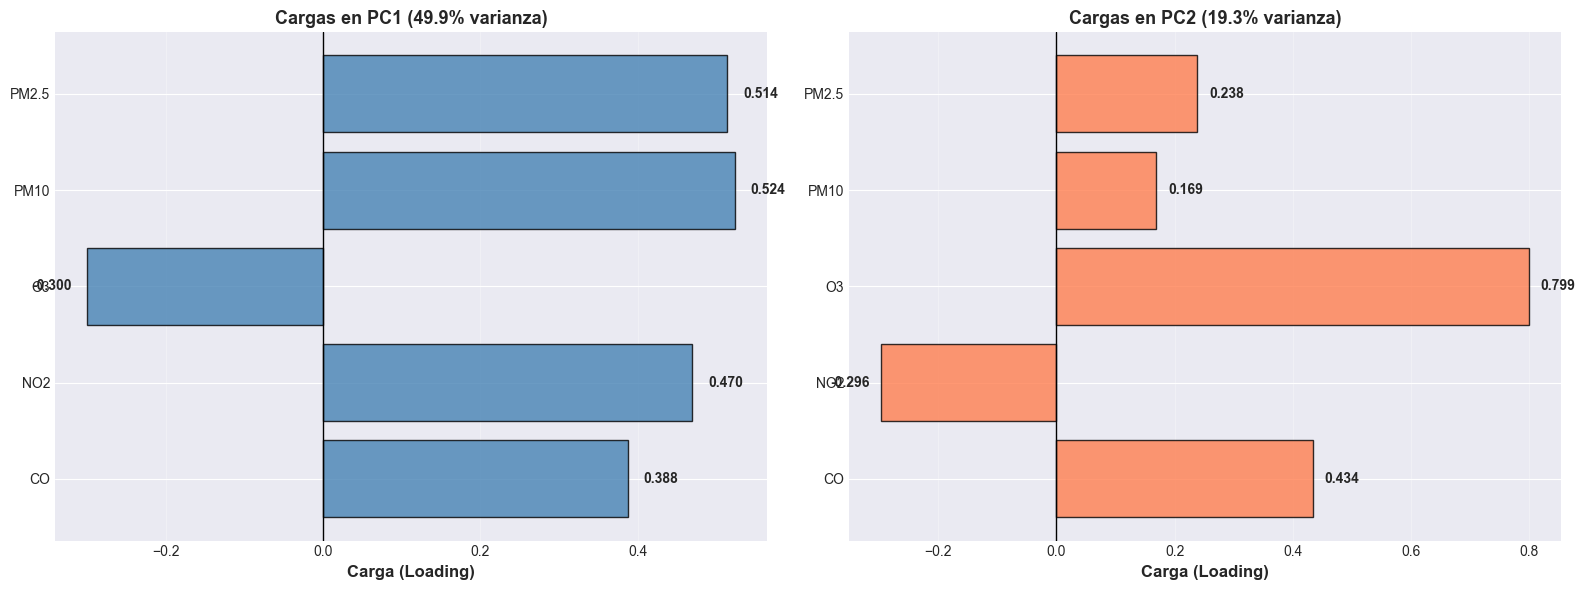

In [65]:
# Matriz de cargas (loadings)
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=componentes_nombres,
    index=contaminantes
)

print("=" * 60)
print("CARGAS FACTORIALES (LOADINGS)")
print("=" * 60)
print(loadings)

# Visualizar loadings para PC1 y PC2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 Loadings
axes[0].barh(contaminantes, loadings['PC1'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Carga (Loading)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Cargas en PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings['PC1']):
    axes[0].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                 va='center', ha='left' if v > 0 else 'right', fontweight='bold')

# PC2 Loadings
axes[1].barh(contaminantes, loadings['PC2'], color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Carga (Loading)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Cargas en PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings['PC2']):
    axes[1].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                 va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretación de Componentes Principales

Basándonos en las cargas factoriales, interpretamos el significado físico/ambiental de cada componente.

In [66]:
# Identificar contaminantes principales por componente
print("=" * 60)
print("INTERPRETACIÓN DE COMPONENTES PRINCIPALES")
print("=" * 60)

for pc in ['PC1', 'PC2']:
    print(f"\n{pc} ({pca_full.explained_variance_ratio_[int(pc[2])-1]*100:.1f}% de varianza):")
    print("-" * 60)
    
    # Ordenar cargas por magnitud absoluta
    cargas_ordenadas = loadings[pc].abs().sort_values(ascending=False)
    
    print("Contaminantes más influyentes (por magnitud):")
    for cont in cargas_ordenadas.index:
        carga = loadings.loc[cont, pc]
        print(f"  {cont:6s}: {carga:+.4f}")
    
    # Interpretar significado
    print("\nInterpretación sugerida:")
    if pc == 'PC1':
        positivos = loadings[loadings['PC1'] > 0.3].index.tolist()
        negativos = loadings[loadings['PC1'] < -0.3].index.tolist()
        if positivos:
            print(f"  Asociado positivamente con: {', '.join(positivos)}")
        if negativos:
            print(f"  Asociado negativamente con: {', '.join(negativos)}")
    elif pc == 'PC2':
        positivos = loadings[loadings['PC2'] > 0.3].index.tolist()
        negativos = loadings[loadings['PC2'] < -0.3].index.tolist()
        if positivos:
            print(f"  Asociado positivamente con: {', '.join(positivos)}")
        if negativos:
            print(f"  Asociado negativamente con: {', '.join(negativos)}")

INTERPRETACIÓN DE COMPONENTES PRINCIPALES

PC1 (49.9% de varianza):
------------------------------------------------------------
Contaminantes más influyentes (por magnitud):
  PM10  : +0.5240
  PM2.5 : +0.5142
  NO2   : +0.4696
  CO    : +0.3877
  O3    : -0.3002

Interpretación sugerida:
  Asociado positivamente con: CO, NO2, PM10, PM2.5
  Asociado negativamente con: O3

PC2 (19.3% de varianza):
------------------------------------------------------------
Contaminantes más influyentes (por magnitud):
  O3    : +0.7993
  CO    : +0.4340
  NO2   : -0.2961
  PM2.5 : +0.2379
  PM10  : +0.1686

Interpretación sugerida:
  Asociado positivamente con: CO, O3


## Biplot PC1–PC2

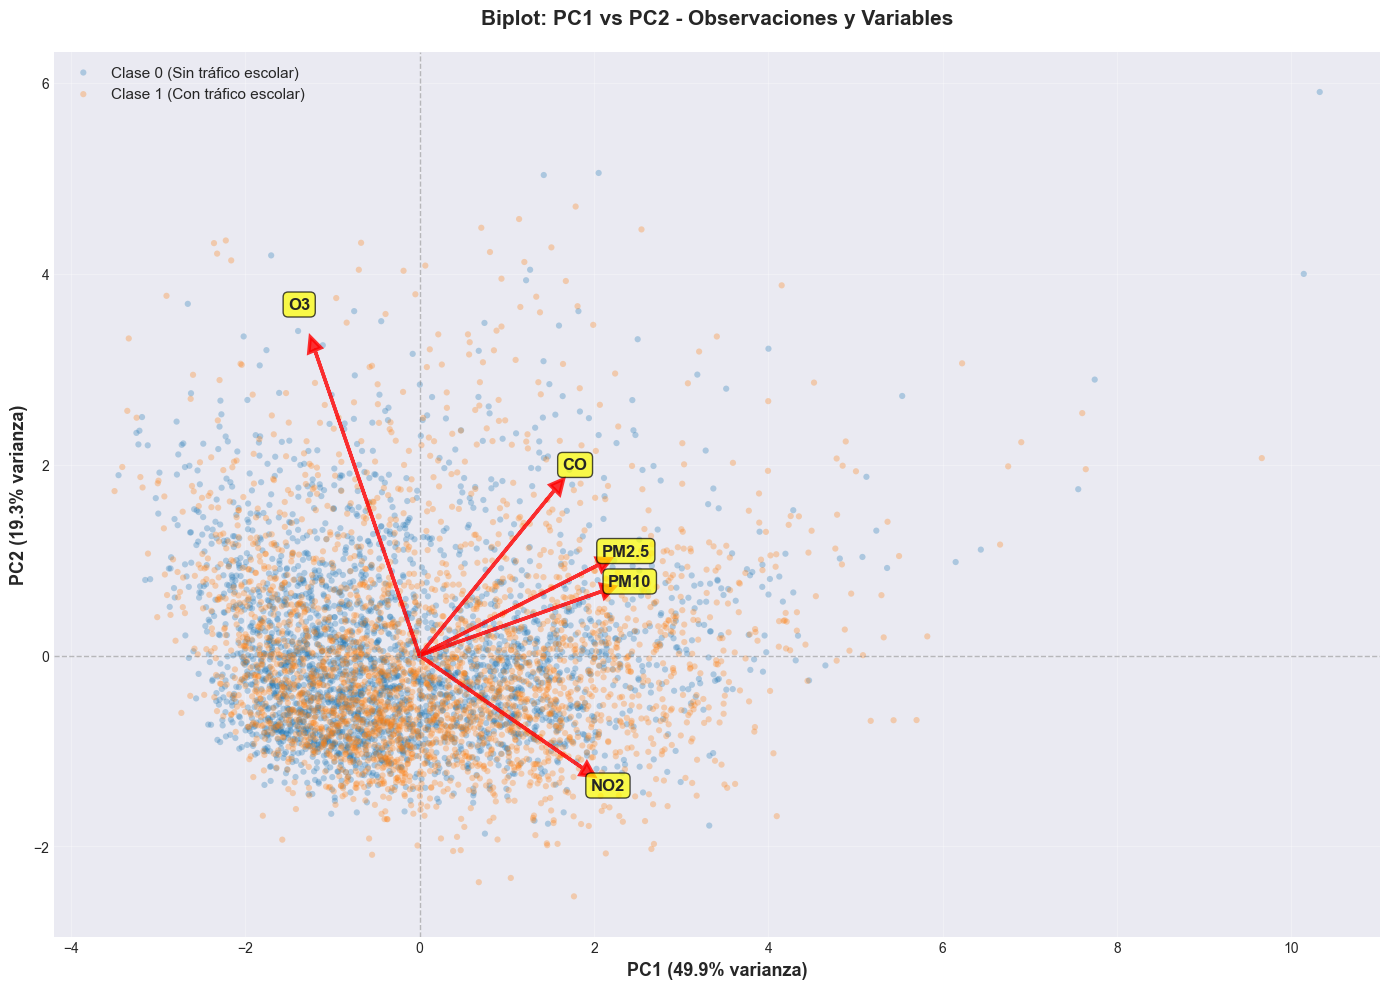

In [67]:
# Preparar datos para biplot
df_biplot = df_pca_scores[['PC1', 'PC2']].copy()
df_biplot['clase'] = df_pca['clase'].values

# Biplot
fig, ax = plt.subplots(figsize=(14, 10))

# Scatter plot de observaciones coloreadas por clase
clases = df_biplot['clase'].unique()
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels_clase = ['Clase 0 (Sin tráfico escolar)', 'Clase 1 (Con tráfico escolar)', 'Clase 2 (Transición)']

for i, clase in enumerate(sorted(clases)):
    mask = df_biplot['clase'] == clase
    ax.scatter(df_biplot.loc[mask, 'PC1'], 
               df_biplot.loc[mask, 'PC2'],
               alpha=0.3, s=20, c=colores[i], 
               label=labels_clase[i], edgecolors='none')

# Dibujar vectores de variables (loadings escalados)
scale = 4  # Factor de escala para visualizar mejor los vectores
for i, contaminante in enumerate(contaminantes):
    ax.arrow(0, 0, 
             loadings.loc[contaminante, 'PC1'] * scale, 
             loadings.loc[contaminante, 'PC2'] * scale,
             head_width=0.15, head_length=0.15, fc='red', ec='red', 
             linewidth=2.5, alpha=0.8)
    ax.text(loadings.loc[contaminante, 'PC1'] * scale * 1.15, 
            loadings.loc[contaminante, 'PC2'] * scale * 1.15,
            contaminante, fontsize=12, fontweight='bold', 
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Líneas de referencia
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Configuración
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)', 
              fontsize=13, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)', 
              fontsize=13, fontweight='bold')
ax.set_title('Biplot: PC1 vs PC2 - Observaciones y Variables', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Separación por Clase en el Espacio PCA

ESTADÍSTICAS DE COMPONENTES PRINCIPALES POR CLASE

Clase 0 (Sin tráfico escolar):
------------------------------------------------------------
PC1 - Media: -0.211, Std: 1.495
PC2 - Media: +0.028, Std: 0.922

Clase 1 (Con tráfico escolar):
------------------------------------------------------------
PC1 - Media: +0.213, Std: 1.633
PC2 - Media: -0.028, Std: 1.041


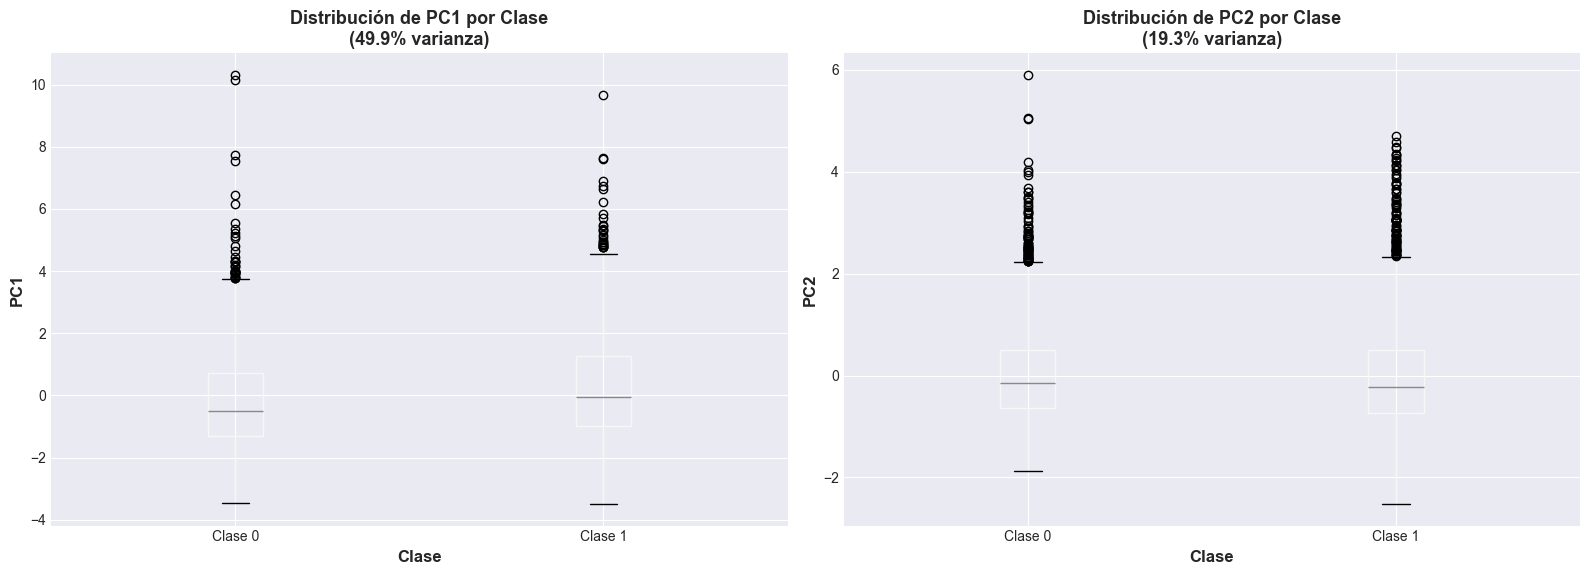

In [68]:
# Estadísticas de PC1 y PC2 por clase
print("=" * 60)
print("ESTADÍSTICAS DE COMPONENTES PRINCIPALES POR CLASE")
print("=" * 60)

# Determinar las clases presentes
clases_presentes = sorted(clases)
labels_clase_dict = {
    0: 'Clase 0 (Sin tráfico escolar)', 
    1: 'Clase 1 (Con tráfico escolar)', 
    2: 'Clase 2 (Transición)'
}

for clase in clases_presentes:
    print(f"\n{labels_clase_dict[int(clase)]}:")
    print("-" * 60)
    mask = df_biplot['clase'] == clase
    print(f"PC1 - Media: {df_biplot.loc[mask, 'PC1'].mean():+.3f}, "
          f"Std: {df_biplot.loc[mask, 'PC1'].std():.3f}")
    print(f"PC2 - Media: {df_biplot.loc[mask, 'PC2'].mean():+.3f}, "
          f"Std: {df_biplot.loc[mask, 'PC2'].std():.3f}")

# Boxplots por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 por clase
df_biplot.boxplot(column='PC1', by='clase', ax=axes[0])
axes[0].set_title(f'Distribución de PC1 por Clase\n({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PC1', fontsize=12, fontweight='bold')
# Establecer etiquetas dinámicamente según las clases presentes
axes[0].set_xticklabels([f'Clase {int(c)}' for c in clases_presentes])
axes[0].get_figure().suptitle('')

# PC2 por clase
df_biplot.boxplot(column='PC2', by='clase', ax=axes[1])
axes[1].set_title(f'Distribución de PC2 por Clase\n({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PC2', fontsize=12, fontweight='bold')
# Establecer etiquetas dinámicamente según las clases presentes
axes[1].set_xticklabels([f'Clase {int(c)}' for c in clases_presentes])
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

# PCA por Temporada (Análisis Complementario)

**Propósito:** Detectar diferencias en la estructura multivariada según la temporada. Identificar si ciertos contaminantes dominan en:
- **Invierno:** Por ejemplo PM (acumulación, inversión térmica)
- **Verano:** Por ejemplo O₃ (fotoquímica)

## Preparación de Datos por Temporada

In [69]:
# Separar datos por temporada
df_verano = df_pca[df_pca['temporada'] == 'verano'].copy()
df_invierno = df_pca[df_pca['temporada'] == 'invierno'].copy()

print("=" * 60)
print("DATOS POR TEMPORADA")
print("=" * 60)
print(f"\nVerano: {len(df_verano)} observaciones ({len(df_verano)/len(df_pca)*100:.1f}%)")
print(f"Invierno: {len(df_invierno)} observaciones ({len(df_invierno)/len(df_pca)*100:.1f}%)")

# Extraer matrices y estandarizar
X_verano = df_verano[contaminantes].values
X_invierno = df_invierno[contaminantes].values

scaler_verano = StandardScaler()
scaler_invierno = StandardScaler()

X_verano_scaled = scaler_verano.fit_transform(X_verano)
X_invierno_scaled = scaler_invierno.fit_transform(X_invierno)

print("\n✓ Datos estandarizados por temporada")

DATOS POR TEMPORADA

Verano: 2742 observaciones (50.1%)
Invierno: 2730 observaciones (49.9%)

✓ Datos estandarizados por temporada


## PCA para Verano

In [70]:
# PCA para verano
pca_verano = PCA()
X_pca_verano = pca_verano.fit_transform(X_verano_scaled)

# Loadings
loadings_verano = pd.DataFrame(
    pca_verano.components_.T,
    columns=componentes_nombres,
    index=contaminantes
)

print("=" * 60)
print("PCA VERANO - VARIANZA EXPLICADA")
print("=" * 60)
for i, var in enumerate(pca_verano.explained_variance_ratio_):
    cumvar = np.cumsum(pca_verano.explained_variance_ratio_)[i]
    print(f"PC{i+1}: {var*100:.2f}% | Acumulada: {cumvar*100:.2f}%")

print("\n" + "=" * 60)
print("CARGAS FACTORIALES - VERANO")
print("=" * 60)
print(loadings_verano[['PC1', 'PC2']])

PCA VERANO - VARIANZA EXPLICADA
PC1: 44.43% | Acumulada: 44.43%
PC2: 24.78% | Acumulada: 69.21%
PC3: 13.22% | Acumulada: 82.42%
PC4: 12.14% | Acumulada: 94.57%
PC5: 5.43% | Acumulada: 100.00%

CARGAS FACTORIALES - VERANO
            PC1       PC2
CO     0.396921  0.456994
NO2    0.425591 -0.422399
O3    -0.033701  0.765392
PM10   0.595284 -0.088006
PM2.5  0.553017  0.138444


## PCA para Invierno

In [71]:
# PCA para invierno
pca_invierno = PCA()
X_pca_invierno = pca_invierno.fit_transform(X_invierno_scaled)

# Loadings
loadings_invierno = pd.DataFrame(
    pca_invierno.components_.T,
    columns=componentes_nombres,
    index=contaminantes
)

print("=" * 60)
print("PCA INVIERNO - VARIANZA EXPLICADA")
print("=" * 60)
for i, var in enumerate(pca_invierno.explained_variance_ratio_):
    cumvar = np.cumsum(pca_invierno.explained_variance_ratio_)[i]
    print(f"PC{i+1}: {var*100:.2f}% | Acumulada: {cumvar*100:.2f}%")

print("\n" + "=" * 60)
print("CARGAS FACTORIALES - INVIERNO")
print("=" * 60)
print(loadings_invierno[['PC1', 'PC2']])

PCA INVIERNO - VARIANZA EXPLICADA
PC1: 51.40% | Acumulada: 51.40%
PC2: 16.44% | Acumulada: 67.84%
PC3: 15.51% | Acumulada: 83.35%
PC4: 10.63% | Acumulada: 93.97%
PC5: 6.03% | Acumulada: 100.00%

CARGAS FACTORIALES - INVIERNO
            PC1       PC2
CO     0.370042  0.297349
NO2    0.455968 -0.326858
O3    -0.387612  0.756017
PM10   0.484307  0.407589
PM2.5  0.519967  0.258955


## Comparación Estacional de Componentes

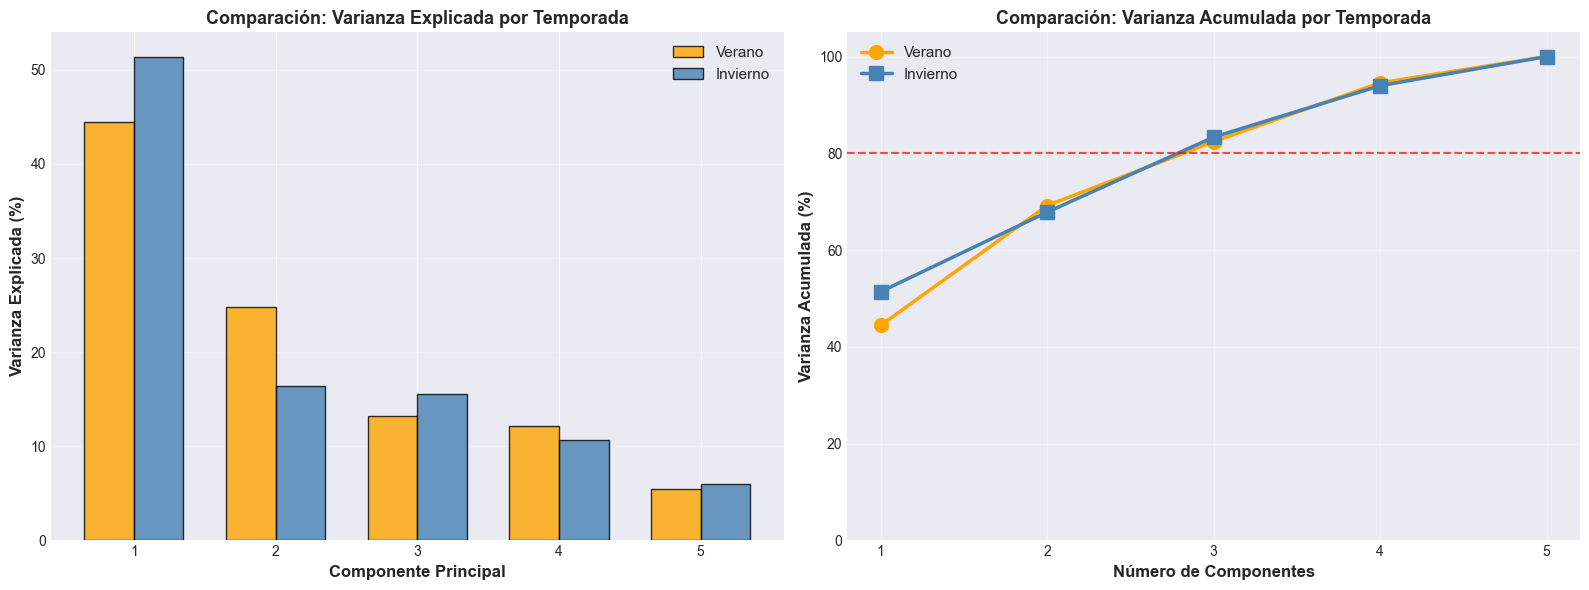

In [72]:
# Comparación de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot comparativo
x = np.arange(1, len(contaminantes) + 1)
width = 0.35

axes[0].bar(x - width/2, pca_verano.explained_variance_ratio_ * 100, 
            width, label='Verano', alpha=0.8, color='orange', edgecolor='black')
axes[0].bar(x + width/2, pca_invierno.explained_variance_ratio_ * 100, 
            width, label='Invierno', alpha=0.8, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación: Varianza Explicada por Temporada', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

# Varianza acumulada comparativa
axes[1].plot(x, np.cumsum(pca_verano.explained_variance_ratio_) * 100, 
             marker='o', linestyle='-', linewidth=2.5, markersize=10, 
             label='Verano', color='orange')
axes[1].plot(x, np.cumsum(pca_invierno.explained_variance_ratio_) * 100, 
             marker='s', linestyle='-', linewidth=2.5, markersize=10, 
             label='Invierno', color='steelblue')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Comparación: Varianza Acumulada por Temporada', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

### Comparación de Cargas Factoriales por Temporada

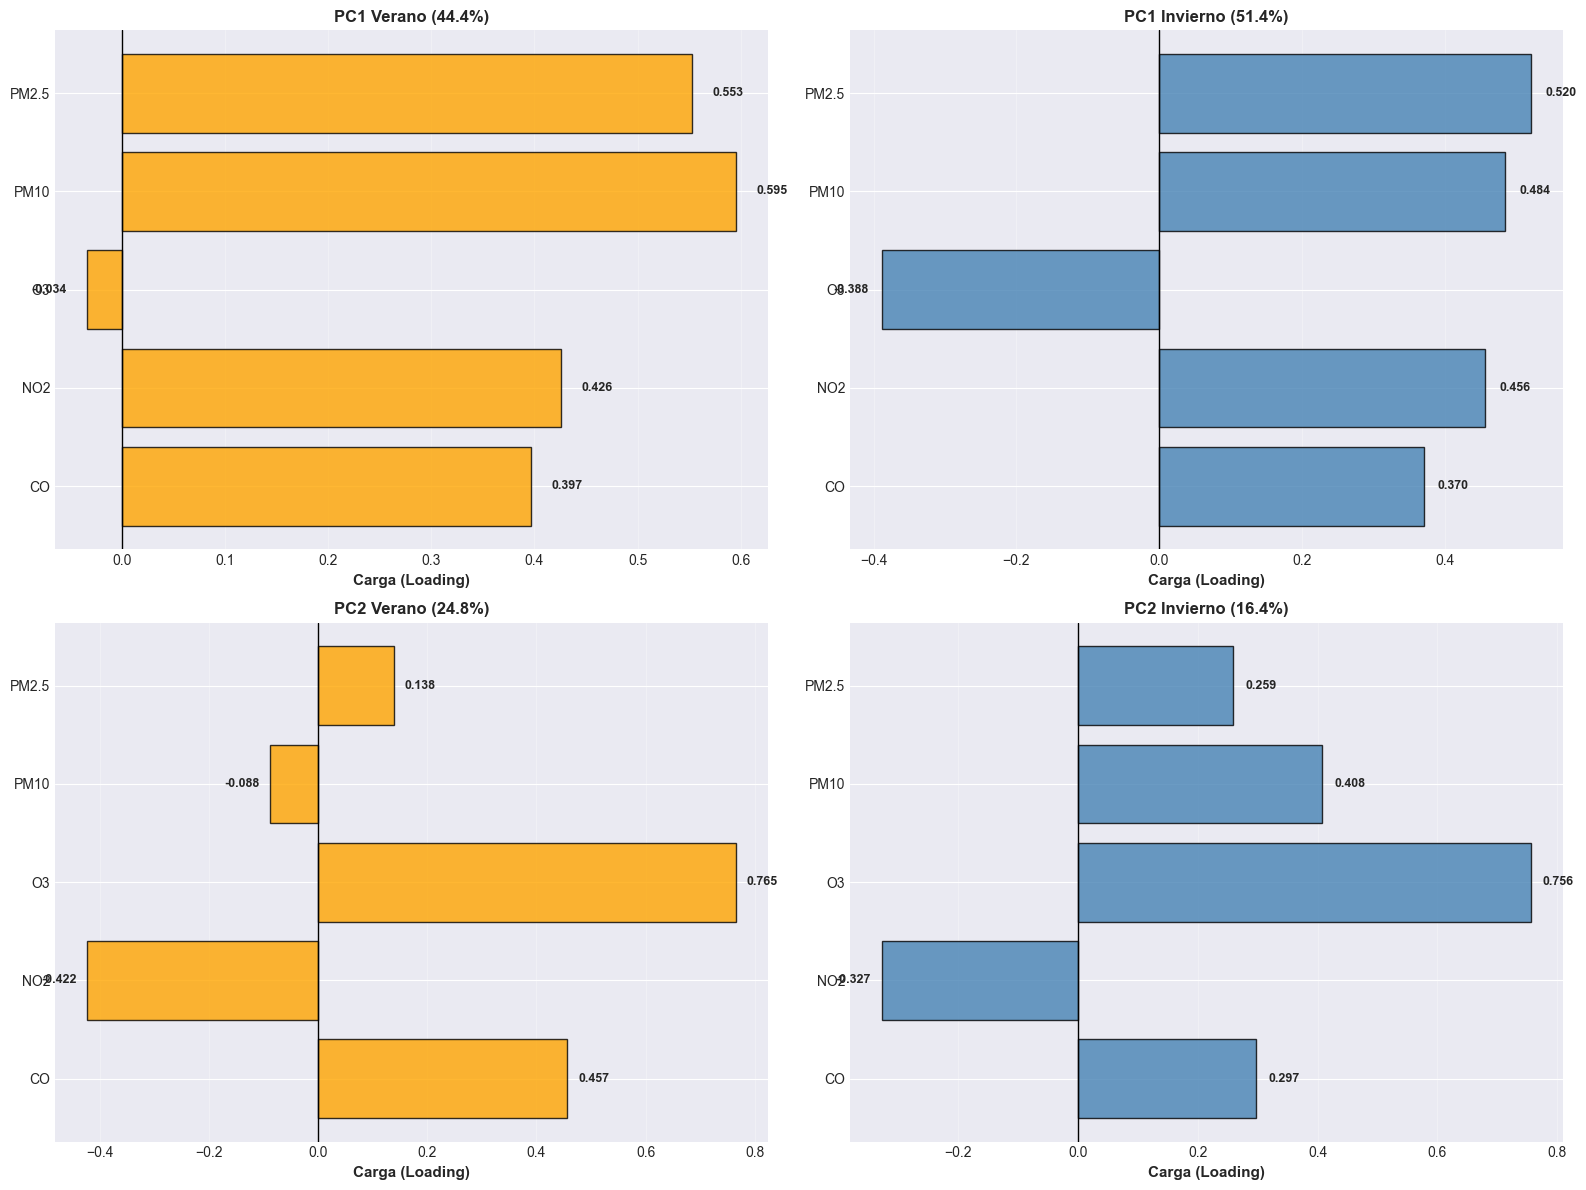

In [73]:
# Comparación de loadings para PC1 y PC2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PC1 - Verano
axes[0, 0].barh(contaminantes, loadings_verano['PC1'], color='orange', edgecolor='black', alpha=0.8)
axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0, 0].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(f'PC1 Verano ({pca_verano.explained_variance_ratio_[0]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_verano['PC1']):
    axes[0, 0].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

# PC1 - Invierno
axes[0, 1].barh(contaminantes, loadings_invierno['PC1'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'PC1 Invierno ({pca_invierno.explained_variance_ratio_[0]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_invierno['PC1']):
    axes[0, 1].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

# PC2 - Verano
axes[1, 0].barh(contaminantes, loadings_verano['PC2'], color='orange', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'PC2 Verano ({pca_verano.explained_variance_ratio_[1]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_verano['PC2']):
    axes[1, 0].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

# PC2 - Invierno
axes[1, 1].barh(contaminantes, loadings_invierno['PC2'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[1, 1].set_title(f'PC2 Invierno ({pca_invierno.explained_variance_ratio_[1]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_invierno['PC2']):
    axes[1, 1].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Análisis de Diferencias Estacionales

In [74]:
# Tabla comparativa de loadings
comparison_df = pd.DataFrame({
    'PC1_Verano': loadings_verano['PC1'],
    'PC1_Invierno': loadings_invierno['PC1'],
    'Dif_PC1': loadings_verano['PC1'] - loadings_invierno['PC1'],
    'PC2_Verano': loadings_verano['PC2'],
    'PC2_Invierno': loadings_invierno['PC2'],
    'Dif_PC2': loadings_verano['PC2'] - loadings_invierno['PC2']
})

print("=" * 80)
print("COMPARACIÓN DE CARGAS FACTORIALES: VERANO vs INVIERNO")
print("=" * 80)
print(comparison_df)

print("\n" + "=" * 80)
print("DIFERENCIAS MÁS NOTABLES")
print("=" * 80)

# PC1
print("\nPC1 - Mayores diferencias absolutas:")
dif_pc1 = comparison_df['Dif_PC1'].abs().sort_values(ascending=False)
for cont in dif_pc1.index[:3]:
    diff = comparison_df.loc[cont, 'Dif_PC1']
    v_ver = comparison_df.loc[cont, 'PC1_Verano']
    v_inv = comparison_df.loc[cont, 'PC1_Invierno']
    print(f"  {cont}: Verano={v_ver:+.3f}, Invierno={v_inv:+.3f}, Diferencia={diff:+.3f}")

# PC2
print("\nPC2 - Mayores diferencias absolutas:")
dif_pc2 = comparison_df['Dif_PC2'].abs().sort_values(ascending=False)
for cont in dif_pc2.index[:3]:
    diff = comparison_df.loc[cont, 'Dif_PC2']
    v_ver = comparison_df.loc[cont, 'PC2_Verano']
    v_inv = comparison_df.loc[cont, 'PC2_Invierno']
    print(f"  {cont}: Verano={v_ver:+.3f}, Invierno={v_inv:+.3f}, Diferencia={diff:+.3f}")

COMPARACIÓN DE CARGAS FACTORIALES: VERANO vs INVIERNO
       PC1_Verano  PC1_Invierno   Dif_PC1  PC2_Verano  PC2_Invierno   Dif_PC2
CO       0.396921      0.370042  0.026879    0.456994      0.297349  0.159645
NO2      0.425591      0.455968 -0.030377   -0.422399     -0.326858 -0.095541
O3      -0.033701     -0.387612  0.353911    0.765392      0.756017  0.009375
PM10     0.595284      0.484307  0.110977   -0.088006      0.407589 -0.495595
PM2.5    0.553017      0.519967  0.033050    0.138444      0.258955 -0.120511

DIFERENCIAS MÁS NOTABLES

PC1 - Mayores diferencias absolutas:
  O3: Verano=-0.034, Invierno=-0.388, Diferencia=+0.354
  PM10: Verano=+0.595, Invierno=+0.484, Diferencia=+0.111
  PM2.5: Verano=+0.553, Invierno=+0.520, Diferencia=+0.033

PC2 - Mayores diferencias absolutas:
  PM10: Verano=-0.088, Invierno=+0.408, Diferencia=-0.496
  CO: Verano=+0.457, Invierno=+0.297, Diferencia=+0.160
  PM2.5: Verano=+0.138, Invierno=+0.259, Diferencia=-0.121


## Biplots por Temporada

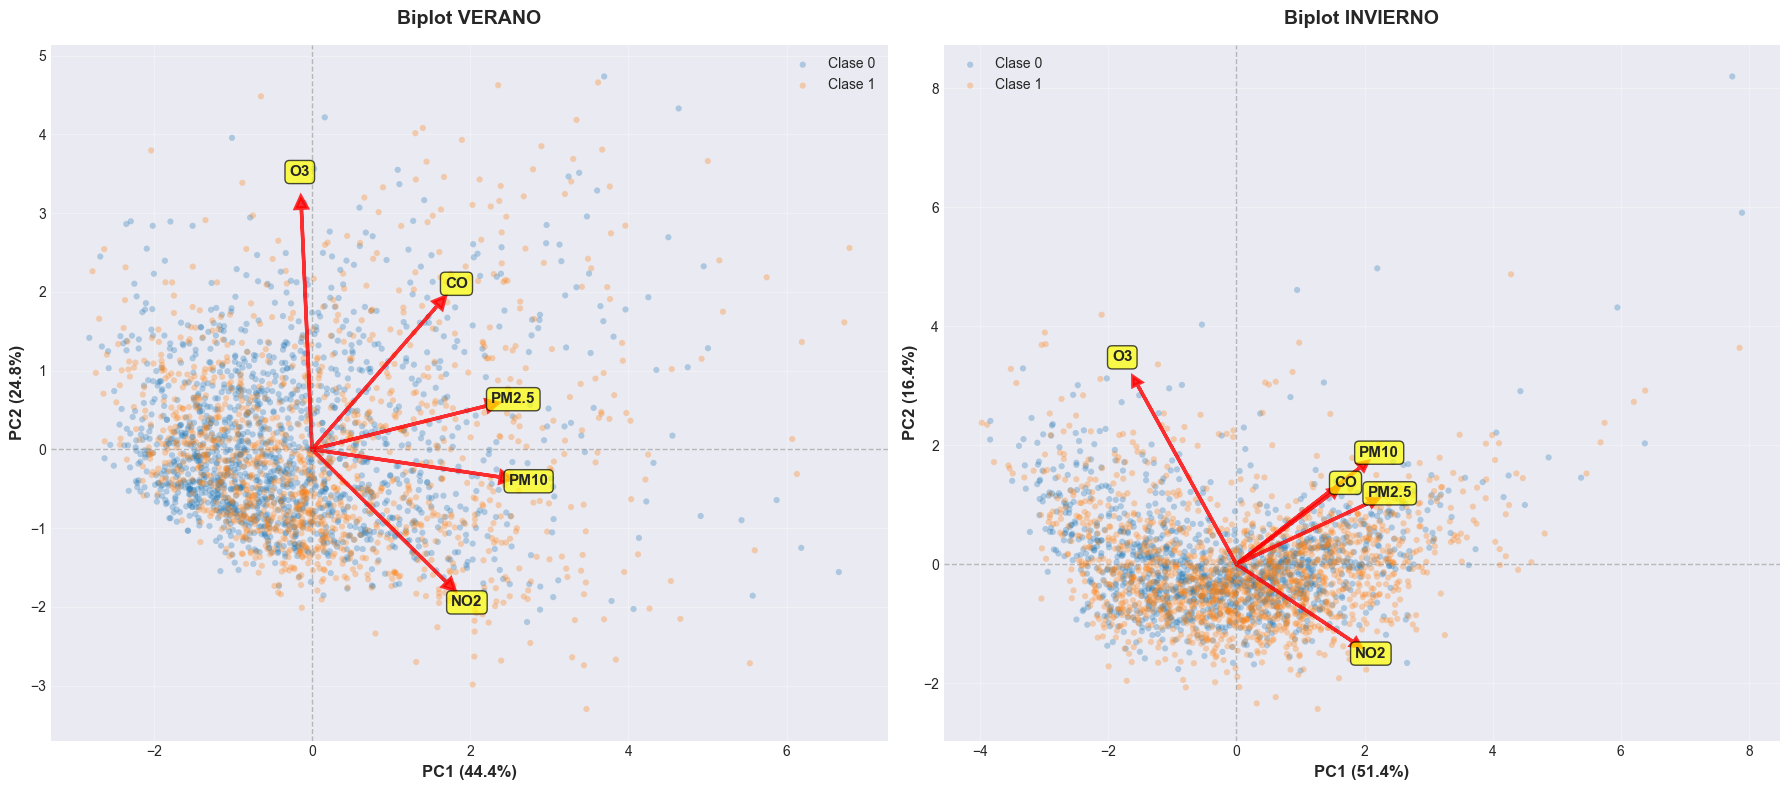

In [75]:
# Preparar datos para biplots
df_biplot_verano = pd.DataFrame(X_pca_verano[:, :2], columns=['PC1', 'PC2'])
df_biplot_verano['clase'] = df_verano['clase'].values

df_biplot_invierno = pd.DataFrame(X_pca_invierno[:, :2], columns=['PC1', 'PC2'])
df_biplot_invierno['clase'] = df_invierno['clase'].values

# Crear biplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Configuración común
scale = 4
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels_clase = ['Clase 0', 'Clase 1', 'Clase 2']

# Biplot VERANO
for i, clase in enumerate(sorted(clases)):
    mask = df_biplot_verano['clase'] == clase
    axes[0].scatter(df_biplot_verano.loc[mask, 'PC1'], 
                   df_biplot_verano.loc[mask, 'PC2'],
                   alpha=0.3, s=20, c=colores[i], 
                   label=labels_clase[i], edgecolors='none')

# Vectores de variables - Verano
for i, contaminante in enumerate(contaminantes):
    axes[0].arrow(0, 0, 
                 loadings_verano.loc[contaminante, 'PC1'] * scale, 
                 loadings_verano.loc[contaminante, 'PC2'] * scale,
                 head_width=0.15, head_length=0.15, fc='red', ec='red', 
                 linewidth=2.5, alpha=0.8)
    axes[0].text(loadings_verano.loc[contaminante, 'PC1'] * scale * 1.15, 
                loadings_verano.loc[contaminante, 'PC2'] * scale * 1.15,
                contaminante, fontsize=11, fontweight='bold', 
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel(f'PC1 ({pca_verano.explained_variance_ratio_[0]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca_verano.explained_variance_ratio_[1]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[0].set_title('Biplot VERANO', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(loc='best', fontsize=10, framealpha=0.9)
axes[0].grid(alpha=0.3)

# Biplot INVIERNO
for i, clase in enumerate(sorted(clases)):
    mask = df_biplot_invierno['clase'] == clase
    axes[1].scatter(df_biplot_invierno.loc[mask, 'PC1'], 
                   df_biplot_invierno.loc[mask, 'PC2'],
                   alpha=0.3, s=20, c=colores[i], 
                   label=labels_clase[i], edgecolors='none')

# Vectores de variables - Invierno
for i, contaminante in enumerate(contaminantes):
    axes[1].arrow(0, 0, 
                 loadings_invierno.loc[contaminante, 'PC1'] * scale, 
                 loadings_invierno.loc[contaminante, 'PC2'] * scale,
                 head_width=0.15, head_length=0.15, fc='red', ec='red', 
                 linewidth=2.5, alpha=0.8)
    axes[1].text(loadings_invierno.loc[contaminante, 'PC1'] * scale * 1.15, 
                loadings_invierno.loc[contaminante, 'PC2'] * scale * 1.15,
                contaminante, fontsize=11, fontweight='bold', 
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel(f'PC1 ({pca_invierno.explained_variance_ratio_[0]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca_invierno.explained_variance_ratio_[1]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[1].set_title('Biplot INVIERNO', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(loc='best', fontsize=10, framealpha=0.9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen y Conclusiones del Análisis PCA

In [76]:
# Resumen cuantitativo final
print("=" * 80)
print("RESUMEN EJECUTIVO DEL ANÁLISIS PCA")
print("=" * 80)

print("\n1. VALIDACIÓN DE SUPUESTOS")
print("-" * 80)
print(f"   KMO Global: {kmo_model:.4f} - {interpretacion}")
print(f"   Prueba de Bartlett: Chi² = {chi_square_value:.2f}, p-valor = {p_value:.2e}")
print("   Conclusión: PCA es apropiado para este dataset")

print("\n2. PCA GENERAL (Dataset Completo)")
print("-" * 80)
print(f"   Varianza explicada por PC1: {pca_full.explained_variance_ratio_[0]*100:.2f}%")
print(f"   Varianza explicada por PC2: {pca_full.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Varianza acumulada PC1+PC2: {(pca_full.explained_variance_ratio_[0] + pca_full.explained_variance_ratio_[1])*100:.2f}%")
print(f"   Total de observaciones: {len(df_pca):,}")

print("\n3. ANÁLISIS POR TEMPORADA")
print("-" * 80)
print(f"   Verano:")
print(f"      - Observaciones: {len(df_verano):,}")
print(f"      - PC1 varianza: {pca_verano.explained_variance_ratio_[0]*100:.2f}%")
print(f"      - PC2 varianza: {pca_verano.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Invierno:")
print(f"      - Observaciones: {len(df_invierno):,}")
print(f"      - PC1 varianza: {pca_invierno.explained_variance_ratio_[0]*100:.2f}%")
print(f"      - PC2 varianza: {pca_invierno.explained_variance_ratio_[1]*100:.2f}%")

print("\n4. CONTAMINANTES CLAVE")
print("-" * 80)
print("   PC1 (Mayor contribución):")
for cont in loadings['PC1'].abs().nlargest(3).index:
    print(f"      - {cont}: {loadings.loc[cont, 'PC1']:+.4f}")
print("   PC2 (Mayor contribución):")
for cont in loadings['PC2'].abs().nlargest(3).index:
    print(f"      - {cont}: {loadings.loc[cont, 'PC2']:+.4f}")

RESUMEN EJECUTIVO DEL ANÁLISIS PCA

1. VALIDACIÓN DE SUPUESTOS
--------------------------------------------------------------------------------
   KMO Global: 0.6997 - Mediocre - PCA puede aplicarse con precaución
   Prueba de Bartlett: Chi² = 7079.90, p-valor = 0.00e+00
   Conclusión: PCA es apropiado para este dataset

2. PCA GENERAL (Dataset Completo)
--------------------------------------------------------------------------------
   Varianza explicada por PC1: 49.89%
   Varianza explicada por PC2: 19.32%
   Varianza acumulada PC1+PC2: 69.21%
   Total de observaciones: 5,472

3. ANÁLISIS POR TEMPORADA
--------------------------------------------------------------------------------
   Verano:
      - Observaciones: 2,742
      - PC1 varianza: 44.43%
      - PC2 varianza: 24.78%
   Invierno:
      - Observaciones: 2,730
      - PC1 varianza: 51.40%
      - PC2 varianza: 16.44%

4. CONTAMINANTES CLAVE
--------------------------------------------------------------------------------
   P